# BloodMNIST (Lab Variant 8): Federated Learning 
****
FL Strategies: Tested under data heterogeneity (FedAvg, FedProx, FedMedian and Krum)\
Dataset: BloodMNIST (8-class, 3-channel, multi-class classification)\
Resolutions tested: 28×28 and 64×64\
Models: Lightweight CNN baseline + ResNet18  
Partitioning: IID and non-IID (Dirichlet α)

## Libraries and Setup

**Setup Instructions**:
1. Install the required version of flower onto the environment.\
    -- pip install torch, medmnist 
2. Install relevant libraries and import.
3. Set the default configurations: seed, num of clients, alpha, local epochs, strategies, model.\
    -- experiment model configuration can override the default settings wherever required
4. Load the bloodmnist data, transform to tensor, normalize and initialize data loader.
5. Create Dirichlet partitioning function to simulate the client partitions. Dirichlet alpha controls heterogeneity.\
    -- test partitioning with different values of alpha
6. Define the CNN and ResNet18 model architecture for training.\
    -- Modify the architecture wherever required to adjust to computational capacity available
7. Define the training methods, evaluation methods and validation metrics.\
    -- Both Test and Validation accuracy, loss, macro-F1 are tracked \
    -- Add additional metrics if required
8. Setup the flower server app and client app.\
    -- Client and server functions are defined\
    -- Communication between server and client is setup\
    -- Method to initialize the chosen strategy\
    -- Logging function\
    -- Flower call method: run_fl_experiment()\
    -- Test run flower
9. Run experiments to test federated learning: change hyperparameters in run_fl_experiment() to adapt to the experimental context. The default configuration is kept constant for all hyperparameters except the ones undergoing test.\
    -- Test impact of client heterogeneity\
    -- Test impact of model architecture\
    -- Test impact of variation in strategies\
    -- Test impact of data poisoning\
    -- Test impact of different local epochs

### 1. Install Dependencies
Install Flower simulation engine, federated datasets utility, MedMNIST, and sklearn for F1 scoring.

In [1]:
!pip install -q "flwr[simulation]>=1.8" flwr-datasets medmnist scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### 2. Imports & Reproducibility

In [2]:
## Imports Libraries
import random, copy
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import OrderedDict
from typing import Dict, List, Tuple, Optional
from sklearn.metrics import f1_score
import json
from datetime import datetime

import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
from torchvision import models, transforms
from torch.utils.data import random_split, DataLoader, Subset

import medmnist
from medmnist import INFO

from flwr.common import NDArrays, Scalar, Metrics, Context, ndarrays_to_parameters, parameters_to_ndarrays
from flwr.client import NumPyClient, ClientApp
from flwr.server import ServerApp, ServerConfig, ServerAppComponents
from flwr.server.strategy import FedAvg, FedMedian, Krum, FedProx
from flwr.simulation import run_simulation

import warnings
warnings.filterwarnings("ignore")

c:\Users\shast\Documents\Data_warehouse\python\pyenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-06-12 13:54:40,740	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


#### Seed: Reproducibility

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## check device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
print(f"MedMNIST v{medmnist.__version__}")

Using device: cpu
MedMNIST v3.0.2


## Data Loading and Preprocessing

### 3. Dataset Configuration – BloodMNIST
BloodMNIST is variant of Medmnist that contains images of various blood cells. \
It is a multi Label classification problem with 8 different cell classes.\
Load BloodMNIST metadata: 3-channel RGB, 8 blood-cell classes, multi-class task.\
DataClass is dynamically resolved from the medmnist registry.

In [4]:
data_flag = 'bloodmnist'
info = INFO[data_flag]
task = info['task']
N_CHANNELS = info['n_channels']   # 3 (RGB)
N_CLASSES = len(info['label'])   # 8 for bloodmnist
DataClass = getattr(medmnist, info['python_class'])

LABEL_NAMES = list(info['label'].values())
print(f"Task: {task}")
print(f"Channels: {N_CHANNELS}")
print(f"Classes: {N_CLASSES}")
print(f"Labels: {LABEL_NAMES}")
LABEL_NAMES_ = [i.split("(")[0].strip() for i in LABEL_NAMES]

Task: multi-class
Channels: 3
Classes: 8
Labels: ['basophil', 'eosinophil', 'erythroblast', 'immature granulocytes(myelocytes, metamyelocytes and promyelocytes)', 'lymphocyte', 'monocyte', 'neutrophil', 'platelet']


### 4. Default Experiment Configuration
Central experiment config - all downstream functions read from these defaults.\
The default hyperparameter settings that all the experiment utilize.\
In each specific experiment, the custom required hyperparameters can override the default values.

In [5]:
## Hyperparameters
IMAGE_SIZE=28       # 28 or 64
BATCH_SIZE=64
NUM_CLIENTS=5        # ≥ 3
NUM_ROUNDS=20       # FL communication rounds
LOCAL_EPOCHS=1      
LR=0.01
MOMENTUM=0.9

## Malicious Client Configurations
MALICIOUS_FRACTION = 0.2 
POISON_STRATEGY = 'random'  # 'random' or 'target'
POISON_TARGET_CLASS = 0     # only used when POISON_STRATEGY == 'target'

# # Partitioning: 'iid' or 'noniid'
# PARTITION_MODE = 'iid'   # set to 'noniid' for heterogeneous

# Non-IID Dirichlet concentration (lower = more heterogeneous)
DIRICHLET_ALPHA = 100 

# Counter Attack Strategy: 'fedavg', 'fedprox', 'fedmedian' or 'krum'
STRATEGY_NAME = 'fedavg'
PROXIMAL_MU = 0.0

# Model: 'cnn' or 'resnet18'
MODEL_NAME = 'cnn'

# Set a base output directory
OUTPUT_DIR = "/content/drive/MyDrive/dfl-mednist-tp" #### replace with your desired path in Google Drive if using Colab

print(f"Image size: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"Clients: {NUM_CLIENTS}")
print(f"Rounds: {NUM_ROUNDS}")
print(f"Dirichlet Alpha: {DIRICHLET_ALPHA}")
print(f"Local Epochs: {LOCAL_EPOCHS}")
print(f"Strategy: {STRATEGY_NAME}")
print(f"proximal μ: {PROXIMAL_MU}")
print(f"Model: {MODEL_NAME}")

Image size: 28x28
Clients: 5
Rounds: 20
Dirichlet Alpha: 100
Local Epochs: 1
Strategy: fedavg
proximal μ: 0.0
Model: cnn


### 5. Data Loader
Build train/val/test loaders at the configured image size.\
Normalise to [-1, 1] with per-channel mean and std of 0.5.\
Centralised loaders are used for the baseline and server-side test evaluation.

In [6]:
DOWNLOAD = True

def make_transform(image_size):
    return transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[.5]*3, std=[.5]*3),
    ])

transform = make_transform(IMAGE_SIZE)

train_dataset_full = DataClass(split='train', transform=transform, download=DOWNLOAD, size=IMAGE_SIZE)
val_dataset = DataClass(split='val', transform=transform, download=DOWNLOAD, size=IMAGE_SIZE)
test_dataset = DataClass(split='test', transform=transform, download=DOWNLOAD, size=IMAGE_SIZE)

# data loaders
train_loader_full = DataLoader(train_dataset_full, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE*2, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE*2, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_dataset_full)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Train: 11959 | Val: 1712 | Test: 3421


#### Montage: View few samples of images from training set of blood cells.

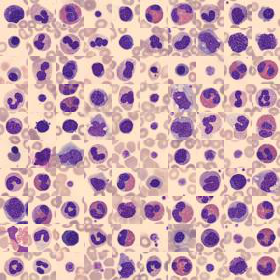

In [7]:
train_dataset_full.montage(length=10)

### 6. Data Partitioning
Dirichlet partitioning function to split data by client for federated learning.\
The partition proportions across clients based on the user defined alpha value.\
Non-IID partition: draw per-class client proportions from Dirichlet(alpha).\
Low alpha concentrates samples in fewer clients while high alpha approaches IID.\
Returns a list of torch Subset objects, one per client.

In [8]:
def dirichlet_partition(dataset, num_clients, alpha, seed=SEED):
    """Non-IID Dirichlet partition - skews class distribution per client."""
    # Extract integer labels
    labels = []
    for _, lbl in dataset:
        if isinstance(lbl, (np.ndarray, torch.Tensor)):
            lbl = int(np.array(lbl).squeeze())
        labels.append(int(lbl))
    labels = np.array(labels)
    n_classes = len(np.unique(labels))

    np.random.seed(seed)
    class_indices = {c: np.where(labels == c)[0].tolist() for c in range(n_classes)}
    # Shuffle within each class
    for c in class_indices:
        np.random.shuffle(class_indices[c])

    client_indices = [[] for _ in range(num_clients)]
    for c in range(n_classes):
        idx = class_indices[c]
        proportions = np.random.dirichlet([alpha] * num_clients)
        proportions = (np.cumsum(proportions) * len(idx)).astype(int)[:-1]
        splits = np.split(idx, proportions)
        for cid, split in enumerate(splits):
            client_indices[cid].extend(split.tolist())

    return [Subset(dataset, idxs) for idxs in client_indices]

### Partition Label Distribution
Visualise class distribution across clients for three alpha values (0.01, 1, 100)


Client 0: 27 samples
Client 1: 3719 samples
Client 2: 2104 samples
Client 3: 849 samples
Client 4: 5260 samples


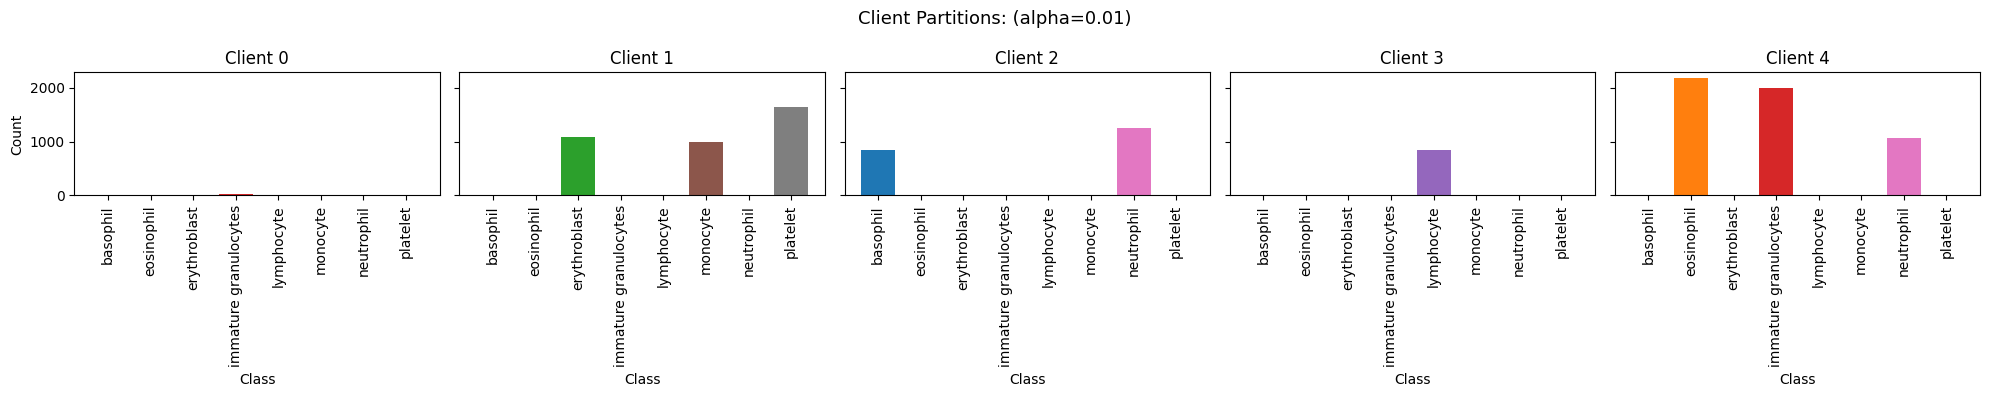

Client 0: 3628 samples
Client 1: 1364 samples
Client 2: 2365 samples
Client 3: 2255 samples
Client 4: 2347 samples


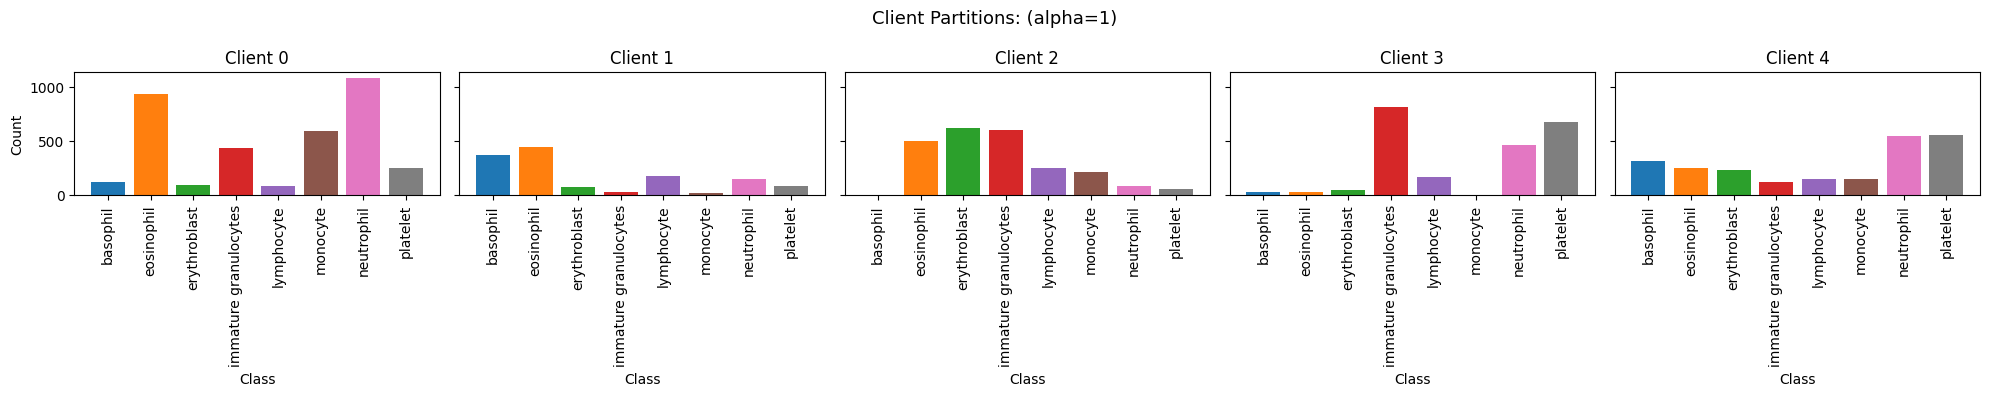

Client 0: 2262 samples
Client 1: 2489 samples
Client 2: 2406 samples
Client 3: 2427 samples
Client 4: 2375 samples


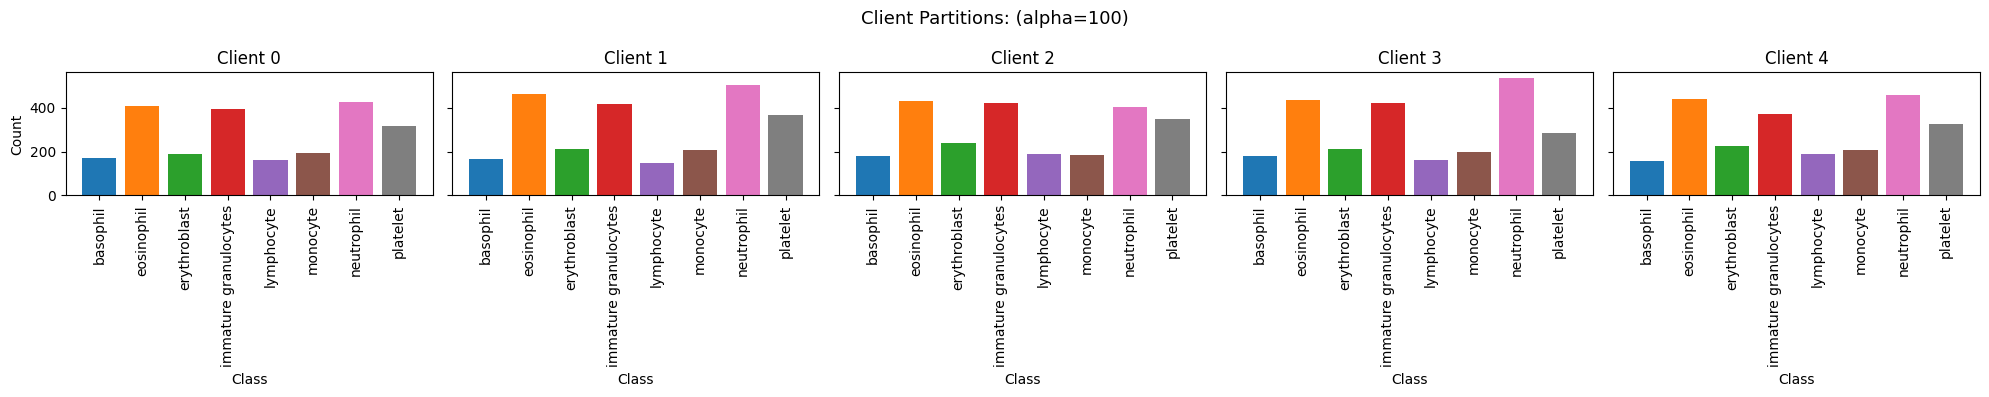

In [9]:
for da in [0.01, 1, 100]:
    partitions = dirichlet_partition(train_dataset_full, NUM_CLIENTS, da)
    for i, p in enumerate(partitions):
        print(f"Client {i}: {len(p)} samples")

    def extract_labels(subset):
        labels = []
        for _, lbl in subset:
            if isinstance(lbl, (np.ndarray, torch.Tensor)):
                lbl = int(np.array(lbl).squeeze())
            labels.append(int(lbl))
        return labels

    fig, axes = plt.subplots(1, NUM_CLIENTS, figsize=(4*NUM_CLIENTS, 4), sharey=True)
    for cid, part in enumerate(partitions):
        lbls = extract_labels(part)
        ax = axes[cid] if NUM_CLIENTS > 1 else axes
        counts = [lbls.count(c) for c in range(N_CLASSES)]
        ax.bar(LABEL_NAMES_, counts, color=sns.color_palette("tab10", N_CLASSES))
        ax.set_title(f"Client {cid}")
        ax.tick_params(axis='x', rotation=90)
        ax.set_xlabel("Class")
        if cid == 0:
            ax.set_ylabel("Count")

    fig.suptitle(f"Client Partitions: (alpha={da})", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"client_partitions_alpha_{da}_{IMAGE_SIZE}.png", dpi=120, bbox_inches='tight')
    plt.show()

## Model Definition

### 7. Model Architectures
LightCNN (baseline): three conv-BN-ReLU blocks with adaptive pooling.\
ResNet18: standard torchvision model with first conv and fc layer replaced to match.\
BloodMNIST input channels, class count, and small spatial dimensions.

In [10]:
### CNN Model Definition
class LightCNN(nn.Module):
    """Lightweight CNN baseline for BloodMNIST."""
    def __init__(self, n_channels=3, n_classes=8):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(n_channels, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, n_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

### ResNet18 Model Definition
def create_resnet18(n_channels=3, n_classes=8, image_size=28):
    model = models.resnet18(weights=None)
    # Adapt first conv for smaller images
    if image_size <= 32:
        model.conv1 = nn.Conv2d(n_channels, 64, kernel_size=3,
                                 stride=1, padding=1, bias=False)
        model.maxpool = nn.Identity()
    else:
        model.conv1 = nn.Conv2d(n_channels, 64, kernel_size=7,
                                 stride=2, padding=3, bias=False)
    model.fc = nn.Linear(model.fc.in_features, n_classes)
    return model

### Select and create model based on configuration
def create_model(name=MODEL_NAME, image_size=IMAGE_SIZE):
    if name == 'cnn':
        return LightCNN(N_CHANNELS, N_CLASSES)
    else:
        return create_resnet18(N_CHANNELS, N_CLASSES, image_size)

# model parameters check
m = create_model()
params = sum(p.numel() for p in m.parameters())
print(f"Model: {MODEL_NAME} | Parameters: {params:,}")

Model: cnn | Parameters: 620,296


### 8. Training & Evaluation Functions
train_one_epoch: standard SGD step with optional FedProx proximal penalty.\
evaluate: returns avg cross-entropy loss, accuracy, and macro F1 on any loader.\
run_centralised: full centralised training loop used as a non-FL upper bound.

In [11]:
## Training and Evaluation Functions
criterion = nn.CrossEntropyLoss()

def train_one_epoch(model, loader, optimizer, proximal_mu, global_params, device):
    model.train()
    total_loss = 0.0
    for images, labels in loader:
        images = images.to(device)
        labels = labels.squeeze(1).long().to(device)
        optimizer.zero_grad()
        out = model(images)
        loss = criterion(out, labels)

        ## if strategy is FedProx, add proximal term to loss
        # Proximal term: μ/2 * ||w - w_global||²
        if proximal_mu > 0.0:
            prox = sum(
                ((p - g) ** 2).sum()
                for p, g in zip(model.parameters(), global_params)
            )
            loss = loss + (proximal_mu / 2.0) * prox

        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
    return total_loss / len(loader.dataset)

def evaluate(model, loader, device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    model.to(device)
    total_loss, y_true, y_pred = 0.0, [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.squeeze(1).long().to(device)
            out  = model(images)
            loss = criterion(out, labels)
            total_loss += loss.item() * images.size(0)
            preds = torch.argmax(out, dim=1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(labels.cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    acc = (np.array(y_pred) == np.array(y_true)).mean()
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    return avg_loss, acc, f1

# test run for centralised baseline
def run_centralised(epochs=5, lr=LR, model_name=MODEL_NAME):
    model = create_model(model_name).to(DEVICE)
    opt   = optim.SGD(model.parameters(), lr=lr, momentum=MOMENTUM)
    history = []
    for epoch in range(1, epochs + 1):
        tr_loss = train_one_epoch(model, train_loader_full, opt, 0.0, [], DEVICE)
        val_loss, val_acc, val_f1 = evaluate(model, val_loader)
        history.append(dict(epoch=epoch, train_loss=tr_loss,
                            val_loss=val_loss, val_acc=val_acc, val_f1=val_f1))
        print(f"Epoch {epoch}/{epochs} | train_loss={tr_loss:.4f} "
              f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} val_f1={val_f1:.4f}")
    test_loss, test_acc, test_f1 = evaluate(model, test_loader)
    print(f"\nTest | loss={test_loss:.4f} acc={test_acc:.4f} f1={test_f1:.4f}")
    return model, history

### Data Poisoning: Label Flipping
Wraps any dataset and replaces true labels with either a random wrong class to simulate a Byzantine data poisoning attack.


In [12]:
### Data Poisoning Attack: Label Flipping
class LabelFlippingDataset(data.Dataset):
    """
    Dataset wrapper that flips labels according to a specified strategy.
    """
    def __init__(self, dataset, n_classes=N_CLASSES, strategy='random', target_class=0, seed=SEED):
        self.dataset = dataset
        self.n_classes = n_classes
        self.strategy = strategy
        self.target_class = target_class
        self.rng = np.random.default_rng(seed)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, label = self.dataset[idx]
        if isinstance(label, (np.ndarray, torch.Tensor)):
            label = int(np.array(label).squeeze())
        else:
            label = int(label)

        if self.strategy == 'target':
            flipped = self.target_class
        else:
            choices = [c for c in range(self.n_classes) if c != label]
            flipped = int(self.rng.choice(choices))

        return image, np.array([flipped], dtype=np.int64)

#### model sanity check

In [13]:
# central_model, central_history = run_centralised(epochs=2)

## Federated Training Setup

### 9. Flower FL Components

get_params: extract model weights as a list of numpy arrays for Flower communication.\
set_params: load a list of numpy arrays back into a model's state dict.

In [14]:
### Parameter helpers ###
def get_params(model):
    return [v.cpu().numpy() for _, v in model.state_dict().items()]

def set_params(model, parameters):
    keys = list(model.state_dict().keys())
    state = OrderedDict({k: torch.tensor(v) for k, v in zip(keys, parameters)})
    model.load_state_dict(state, strict=True)

NumPyClient subclass: receives global parameters, trains locally, returns updated weights.\
FedProx proximal term is applied inside fit() when proximal_mu > 0.

In [15]:
################## CLIENT ##################
# Resolve device safely - works whether or not CUDA is available
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Host device: {DEVICE}")

class FlowerClient(NumPyClient):
    def __init__(self, trainloader, valloader, model_name=MODEL_NAME,
                 local_epochs=LOCAL_EPOCHS, lr=LR, proximal_mu=0.0):
        self.trainloader = trainloader
        self.valloader = valloader
        self.local_epochs = local_epochs
        self.lr = lr
        self.proximal_mu = proximal_mu   # 0.0 means standard FedAvg/FedMedian/Krum behaviour
        self.model_name = model_name
        self.model = create_model(model_name)

    @property
    def device(self):
        return torch.device("cuda" if torch.cuda.is_available() else "cpu")

    def fit(self, parameters, config):
        device = self.device
        self.model.to(device)
        print(f"  Client running on: {device}")
        set_params(self.model, parameters)
        opt = optim.SGD(self.model.parameters(), lr=self.lr, momentum=MOMENTUM)
        # Keep a frozen copy of the global model for the proximal penalty
        global_params = [p.detach().clone() for p in self.model.parameters()]
        print(f"local_epochs={self.local_epochs}, lr={self.lr}, proximal_mu={self.proximal_mu}")
        for _ in range(self.local_epochs):
            train_one_epoch(self.model, self.trainloader, opt, self.proximal_mu, global_params, device)
        return get_params(self.model), len(self.trainloader.dataset), {}

    def evaluate(self, parameters, config):
        device = self.device
        self.model.to(device)
        set_params(self.model, parameters)
        loss, acc, f1 = evaluate(self.model, self.valloader, device)
        return float(loss), len(self.valloader.dataset), {"accuracy": acc, "f1": f1}

Host device: cpu


Factory that returns a client_fn closure over the partition list.\
Assigns the first n_malicious partition IDs as attackers and wraps their dataset with LabelFlippingDataset before creating the DataLoader.

In [16]:
######### CLIENT FUNCTION #########
def make_client_fn(partitions, model_name=MODEL_NAME, local_epochs=LOCAL_EPOCHS, proximal_mu=0.0, 
                   malicious_fraction=0.0, poison_strategy='random', poison_target_class=0):    
    num_clients = len(partitions)
    n_malicious = int(np.floor(malicious_fraction * num_clients))
    malicious_ids = set(range(n_malicious))   # first n clients are malicious

    if n_malicious > 0:
        print(f" Malicious clients : {sorted(malicious_ids)} "
              f"({n_malicious}/{num_clients}, strategy='{poison_strategy}')")

    def client_fn(context: Context):
        pid = int(context.node_config["partition-id"])
        part = partitions[pid]

        # Poison the partition if this client is malicious
        if pid in malicious_ids:
            part = LabelFlippingDataset(part, n_classes=N_CLASSES, strategy=poison_strategy, 
                                        target_class=poison_target_class)

        val_sz = max(1, int(len(part) * 0.1))
        train_sz = len(part) - val_sz
        tr, va = random_split(part, [train_sz, val_sz], generator=torch.Generator().manual_seed(SEED))
        tr_loader = DataLoader(tr, BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=False)
        va_loader = DataLoader(va, BATCH_SIZE*2, shuffle=False, num_workers=2, pin_memory=False)

        return FlowerClient(tr_loader, va_loader, model_name, proximal_mu=proximal_mu, local_epochs=local_epochs).to_client()

    return client_fn

Aggregates per-client accuracy and F1 weighted by local dataset size matching the standard federated evaluation protocol.

In [17]:
#### AGGREGATE METRICS #####
def weighted_average(metrics: List[Tuple[int, Metrics]]) -> Metrics:
    total = sum(n for n, _ in metrics)
    acc = sum(n * m["accuracy"] for n, m in metrics) / total
    f1 = sum(n * m["f1"] for n, m in metrics) / total
    return {"accuracy": acc, "f1": f1}

### Logging the parameters and metrics
Wraps any Flower strategy and records val_loss, accuracy, and F1 after each aggregate_evaluate call.\
Server-side test evaluation appended.

In [18]:
############## LOGGING ##############
class LoggingStrategy:
    """Records per-round metrics."""

    def __init__(self, strategy):
        self._strategy = strategy
        self.history = []
        self.pending_test = {}

    def __getattr__(self, name):
        return getattr(self._strategy, name)
    
    def aggregate_evaluate(self, server_round, results, failures):
        aggregated = self._strategy.aggregate_evaluate(server_round, results, failures)
        if aggregated is not None:
            loss, metrics = aggregated
            self.history.append({
                "round": server_round,
                "val_loss": loss,
                "accuracy": metrics.get("accuracy", float("nan")),
                "f1": metrics.get("f1", float("nan")),
                "test_loss": float("nan"),
                "test_acc": float("nan"),
                "test_f1": float("nan"),
            })
        return aggregated

    def configure_fit(self, server_round, parameters, client_manager):
        return self._strategy.configure_fit(server_round, parameters, client_manager)

    def configure_evaluate(self, server_round, parameters, client_manager):
        return self._strategy.configure_evaluate(server_round, parameters, client_manager)

    def aggregate_fit(self, server_round, results, failures):
        return self._strategy.aggregate_fit(server_round, results, failures)

    def evaluate(self, server_round, parameters):
        return self._strategy.evaluate(server_round, parameters)

    def initialize_parameters(self, client_manager):
        return self._strategy.initialize_parameters(client_manager)

### 10. Execution Methods: FL Experiment
Initializes the Flower strategy with shared configuration.\
Krum receives n_malicious so its selection budget matches the experiment setup.\
FedProx proximal_mu is fixed at the class level and passed from run_fl_experiment.

In [19]:
### Initialize the chosen strategy with appropriate parameters
def build_strategy(name, model, num_clients, n_malicious=0):
    """Return the chosen Flower strategy."""
    ndarrays = get_params(model)
    init_params = ndarrays_to_parameters(ndarrays)

    common = dict(
        fraction_fit = 1.0,
        fraction_evaluate = 1.0,
        min_fit_clients = num_clients,
        min_evaluate_clients = num_clients,
        min_available_clients = num_clients,
        evaluate_metrics_aggregation_fn = weighted_average,
        initial_parameters = init_params,
    )

    if name == 'fedavg':
        return FedAvg(**common)
    elif name == 'fedmedian':
        return FedMedian(**common)
    elif name == 'fedprox':
        return FedProx(proximal_mu=0.1, **common)   # proximal_mu is the μ penalty term
    elif name == 'krum':
        return Krum(num_malicious_clients=n_malicious, min_fit_clients=num_clients,
                min_evaluate_clients=num_clients, min_available_clients=num_clients,
                evaluate_metrics_aggregation_fn=weighted_average,
                initial_parameters=init_params)
    else:
        raise ValueError(f"Unknown strategy: {name!r}. "
                         f"Choose from: fedavg, fedmedian, fedprox, krum")

In [20]:
##### GPU CONFIGURATION #####
# Detect how much GPU to give each worker
def get_backend_config(num_clients: int) -> dict:
    if torch.cuda.is_available():
        # Give each client a fraction of one GPU
        # e.g. 5 clients → 0.2 GPU each (they share the physical GPU)
        gpu_per_client = 1.0 / num_clients
        print(f"GPU detected — allocating {gpu_per_client:.2f} GPU per client")
        return {"client_resources": {"num_cpus": 1, "num_gpus": gpu_per_client}}
    else:
        print("No GPU detected — running on CPU")
        return {"client_resources": {"num_cpus": 1, "num_gpus": 0.0}}

Single entry point for all experiments: builds dataset, partitions, strategy, server app, and client app, then runs the simulation.\
Injects a server-side test evaluation into strategy. Evaluate on the held-out test set after every round.\
Merges test metrics into the round history before returning.

In [21]:
def run_fl_experiment(
        strategy_name = STRATEGY_NAME,
        model_name = MODEL_NAME,
        image_size = IMAGE_SIZE,
        local_epochs = LOCAL_EPOCHS,
        num_clients = NUM_CLIENTS,
        num_rounds = NUM_ROUNDS,
        alpha = DIRICHLET_ALPHA,
        proximal_mu = PROXIMAL_MU,
        malicious_fraction = 0.0,
        poison_strategy = 'random',
        poison_target_class= 0,
):
    """Full FL experiment returning the round history."""

    n_malicious = int(np.floor(malicious_fraction * num_clients))
    print(f"\n{'='*100}")
    print(f"Experiment: strategy={strategy_name} | model={model_name} | "
          f"size={image_size} | alpha={alpha} | num_clients={num_clients} | rounds={num_rounds} | "
          f" mu={proximal_mu if strategy_name=='fedprox' else 'n/a'}")
    print(f" malicious={n_malicious}/{num_clients} ({malicious_fraction:.0%})  poison='{poison_strategy}'")
    print(f"{'='*100}\n")

    # Partitions
    tf = make_transform(image_size)
    ds_train = DataClass(split='train', transform=tf, download=True, size=image_size)
    ds_test = DataClass(split='test', transform=tf, download=True, size=image_size)
    test_loader_exp = DataLoader(ds_test, BATCH_SIZE * 2,shuffle=False, num_workers=2, pin_memory=True)

    parts = dirichlet_partition(ds_train, num_clients, alpha)
    mu = proximal_mu if strategy_name == 'fedprox' else 0.0

    # Strategy (with logging wrapper)
    global_model = create_model(model_name, image_size)
    base_strategy = build_strategy(strategy_name, global_model, num_clients, n_malicious=n_malicious)
    logged_strategy = LoggingStrategy(base_strategy)
    eval_model = create_model(model_name, image_size)
    original_strategy_evaluate = base_strategy.evaluate

    # test evaluation wrapper
    def evaluate_with_test(server_round, parameters):
        result = original_strategy_evaluate(server_round, parameters)

        # Load global parameters into the proxy model and evaluate on test set
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        set_params(eval_model, parameters_to_ndarrays(parameters))
        test_loss, test_acc, test_f1 = evaluate(eval_model, test_loader_exp, device)
        logged_strategy.pending_test[server_round] = {
            "test_loss": test_loss,
            "test_acc":  test_acc,
            "test_f1":   test_f1,
        }
        print(f"  [Round {server_round}] test_loss={test_loss:.4f}  "
              f"test_acc={test_acc:.4f}  test_f1={test_f1:.4f}")
        return result

    base_strategy.evaluate = evaluate_with_test

    # server_fn
    def server_fn(context: Context):
        return ServerAppComponents(
            strategy = logged_strategy,
            config = ServerConfig(num_rounds=num_rounds),
        )

    # client_fn
    server_app = ServerApp(server_fn=server_fn)
    client_app = ClientApp(client_fn=make_client_fn(parts, model_name, local_epochs=local_epochs, 
                                                    proximal_mu=mu, malicious_fraction=malicious_fraction,
                                                    poison_strategy=poison_strategy,poison_target_class=poison_target_class))

    run_simulation(
        server_app = server_app,
        client_app = client_app,
        num_supernodes = num_clients,
        backend_config = get_backend_config(num_clients),
    )
    
    # Merge test metrics into the round history
    for entry in logged_strategy.history:
        r = entry["round"]
        if r in logged_strategy.pending_test:
            entry.update(logged_strategy.pending_test[r])

    return logged_strategy.history

#### Test Experiment (configured above)

In [22]:
# history = run_fl_experiment()

# # Print summary
# print("\nRound | Val Loss | Accuracy | F1")
# print("-" * 40)
# for r in history:
#     print(f"  {r['round']:2d}  |  {r['val_loss']:.4f}  |  {r['accuracy']:.4f}  | {r['f1']:.4f}")

### 11. Plotting Utilities

In [ ]:
########################## Saving and Plotting Utilities ##########################
from google.colab import drive ### only for Colab; remove if running locally
from sklearn import metrics
import os

# Mount Google Drive and create output directory if using Colab; adjust path as needed for local or other environments
drive.mount("/content/drive")
os.makedirs(OUTPUT_DIR, exist_ok=True)

def save_history(histories: dict, filename: str):
    path = os.path.join(OUTPUT_DIR, filename)
    summary = {}
    for label, hist in histories.items():
        if hist:
            last = hist[-1]
            summary[label] = {
                "final_val_loss": last.get("val_loss", float("nan")),
                "final_val_acc": last.get("accuracy", float("nan")),
                "final_val_f1": last.get("f1", float("nan")),
                "final_test_loss": last.get("test_loss", float("nan")),
                "final_test_acc": last.get("test_acc", float("nan")),
                "final_test_f1": last.get("test_f1", float("nan"))
            }

    out = {
        "saved_at":datetime.now().isoformat(),
        "summary":summary,
        "runs":{label: hist for label, hist in histories.items()},
    }
    with open(path, "w") as f:
        json.dump(out, f, indent=2)
    print(f"Saved: {path}")

def plot_history(histories: dict, title: str, filename: str):
    metrics = [
        ("val_loss", "Val Loss", "-"),
        ("accuracy", "Val Accuracy", "-"),
        ("f1", "Val Macro F1",  "-"),
        ("test_loss", "Test Loss", "--"),
        ("test_acc", "Test Accuracy", "--"),
        ("test_f1", "Test Macro F1", "--")
    ]
    fig, axes = plt.subplots(2, 3, figsize=(18, 8))
    axes = axes.flatten()

    for ax, (key, ylabel, ls) in zip(axes, metrics):
        for label, hist in histories.items():
            rounds = [r["round"] for r in hist]
            vals   = [r.get(key, float("nan")) for r in hist]
            ax.plot(rounds, vals, marker='o', linestyle=ls, label=label)
        ax.set_xlabel("Round")
        ax.set_ylabel(ylabel)
        ax.set_title(ylabel)
        ax.legend(fontsize=7)
        ax.grid(True, linestyle='--', alpha=0.5)

    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()

    png_path = os.path.join(OUTPUT_DIR, filename + ".png")
    plt.savefig(png_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f"Saved: {png_path}")

    json_filename = filename + ".json"
    save_history(histories, json_filename)

## Federated Learning Experiments

### 12. Experiment Set 1 - IID vs Non-IID (FedAvg, CNN, 28×28)
Compare FedAvg convergence under near-IID (alpha=100) and extreme non-IID (alpha=0.01) to quantify the performance penalty of data heterogeneity.

In [ ]:
exp1_iid = run_fl_experiment(strategy_name='fedavg', model_name='cnn', image_size=28, alpha=100, num_rounds=20)
exp1_noniid = run_fl_experiment(strategy_name='fedavg', model_name='cnn', image_size=28, alpha=0.01, num_rounds=20)

# Print summary
print("\nExperiment | Round | Val Loss | Accuracy | F1 | Test Loss | Test Accuracy | Test F1")
print("-" * 90)
for r in exp1_iid:
    print(f" IID α=100 |{r['round']:2d}  |  {r['val_loss']:.4f}  |  {r['accuracy']:.4f}  | {r['f1']:.4f} | {r.get('test_loss', float('nan')):.4f}  |  {r.get('test_acc', float('nan')):.4f}  | {r.get('test_f1', float('nan')):.4f}")
print("-" * 90)
for r in exp1_noniid:
    print(f" Non-IID α=0.01 |{r['round']:2d}  |  {r['val_loss']:.4f}  |  {r['accuracy']:.4f}  | {r['f1']:.4f} | {r.get('test_loss', float('nan')):.4f}  |  {r.get('test_acc', float('nan')):.4f}  | {r.get('test_f1', float('nan')):.4f}")

In [ ]:
plot_history(
    {"IID α=100": exp1_iid, "Non-IID α=0.01": exp1_noniid},
    title = "IID vs Non-IID – FedAvg | CNN | 28×28",
    filename = "exp1_heterogeneity_fedavg_cnn_28"
)

### 13. Experiment Set 2 - CNN vs ResNet18 (FedAvg, IID, 28×28)
Benchmark the lightweight CNN against ResNet18 under identical IID FL conditions to assess the accuracy-compute trade-off.

In [ ]:

exp2_resnet = run_fl_experiment(strategy_name='fedavg', model_name='resnet18', image_size=28, num_rounds=20)
exp2_cnn = run_fl_experiment(strategy_name='fedavg', model_name='cnn', image_size=28, num_rounds=20)

# Print summary
print("\nExperiment | Round | Val Loss | Accuracy | F1 | Test Loss | Test Accuracy | Test F1")
print("-" * 90)
for r in exp2_cnn:
    print(f" CNN |{r['round']:2d}  |  {r['val_loss']:.4f}  |  {r['accuracy']:.4f}  | {r['f1']:.4f} | {r.get('test_loss', float('nan')):.4f}  |  {r.get('test_acc', float('nan')):.4f}  | {r.get('test_f1', float('nan')):.4f}")
print("-" * 90)
for r in exp2_resnet:
    print(f" ResNet18 |{r['round']:2d}  |  {r['val_loss']:.4f}  |  {r['accuracy']:.4f}  | {r['f1']:.4f} | {r.get('test_loss', float('nan')):.4f}  |  {r.get('test_acc', float('nan')):.4f}  | {r.get('test_f1', float('nan')):.4f}")


In [ ]:
plot_history(
    {"CNN": exp2_cnn, "ResNet18": exp2_resnet},
    title = "CNN vs ResNet18: FedAvg | IID | 28×28",
    filename = "exp2_model_fedavg_iid_28"
)

### 14. Experiment Set 3 - FedAvg vs FedProx vs FedMedian vs Krum (IID & Non-IID, CNN, 28×28)
Run all four strategies under clean IID conditions to isolate the effect of aggregation algorithm from data heterogeneity.

In [ ]:
exp3_fedmedian = run_fl_experiment(strategy_name='fedmedian',model_name='cnn', image_size=28, num_rounds=20)
exp3_krum = run_fl_experiment(strategy_name='krum', model_name='cnn', image_size=28, num_rounds=20)
exp3_fedavg = run_fl_experiment(strategy_name='fedavg', model_name='cnn', image_size=28, num_rounds=20)
exp3_fedprox = run_fl_experiment(strategy_name='fedprox', proximal_mu=0.1, model_name='cnn', image_size=28, num_rounds=20)

# Print summary
print("\nAlgorithm | Round | Val Loss | Accuracy | F1 | Test Loss | Test Accuracy | Test F1")
print("-" * 90)
for r in exp3_fedmedian:
    print(f"  FedMedian | {r['round']:2d}  |  {r['val_loss']:.4f}  |  {r['accuracy']:.4f}  | {r['f1']:.4f} | {r.get('test_loss', float('nan')):.4f}  |  {r.get('test_acc', float('nan')):.4f}  | {r.get('test_f1', float('nan')):.4f}")

for r in exp3_krum:
    print(f"  Krum | {r['round']:2d}  |  {r['val_loss']:.4f}  |  {r['accuracy']:.4f}  | {r['f1']:.4f}" | f" | {r.get('test_loss', float('nan')):.4f}  |  {r.get('test_acc', float('nan')):.4f}  | {r.get('test_f1', float('nan')):.4f}")

for r in exp3_fedavg:
    print(f"  FedAvg | {r['round']:2d}  |  {r['val_loss']:.4f}  |  {r['accuracy']:.4f}  | {r['f1']:.4f}" | f" | {r.get('test_loss', float('nan')):.4f}  |  {r.get('test_acc', float('nan')):.4f}  | {r.get('test_f1', float('nan')):.4f}")

for r in exp3_fedprox:
    print(f"  FedProx | {r['round']:2d}  |  {r['val_loss']:.4f}  |  {r['accuracy']:.4f}  | {r['f1']:.4f} | {r.get('test_loss', float('nan')):.4f}  |  {r.get('test_acc', float('nan')):.4f}  | {r.get('test_f1', float('nan')):.4f}")

In [ ]:
plot_history(
    {"FedMedian": exp3_fedmedian, "Krum": exp3_krum, "FedAvg": exp3_fedavg, "FedProx": exp3_fedprox},
    title = "Strategy Comparison - IID | CNN | 28×28",
    filename = "exp3_strategy_iid_cnn_28"
)

In [24]:
exp3_fedmedian = run_fl_experiment(strategy_name='fedmedian',model_name='cnn', image_size=28, num_rounds=20, alpha=0.01)
exp3_krum = run_fl_experiment(strategy_name='krum', model_name='cnn', image_size=28, num_rounds=20, alpha=0.01)
exp3_fedavg = run_fl_experiment(strategy_name='fedavg', model_name='cnn', image_size=28, num_rounds=20, alpha=0.01)
exp3_fedprox = run_fl_experiment(strategy_name='fedprox', proximal_mu=0.1, model_name='cnn', image_size=28, num_rounds=20, alpha=0.01)

plot_history(
    {"FedMedian": exp3_fedmedian, "Krum": exp3_krum, "FedAvg": exp3_fedavg, "FedProx": exp3_fedprox},
    title = "Strategy Comparison - Non-IID | CNN | 28×28",
    filename = "exp3_strategy_noniid_cnn_28"
)

### 15. Experiment Set 4 - Resolution 28×28 vs 64×64 (FedAvg, CNN, Non-IID)
Compare 28x28 and 64x64 under non-IID conditions to assess whether higher resolution improves accuracy enough to justify the increased communication cost.

In [ ]:
exp4_28 = run_fl_experiment(strategy_name='fedavg', model_name='cnn', image_size=28, alpha=0.01,num_rounds=20)
exp4_64 = run_fl_experiment(strategy_name='fedavg', model_name='cnn', image_size=64, alpha=0.01,num_rounds=20)

# Print summary
print("\nExperiment | Round | Val Loss | Accuracy | F1 | Test Loss | Test Accuracy | Test F1")
print("-" * 90)
for r in exp4_28:
    print(f" 28×28 | {r['round']:2d}  |  {r['val_loss']:.4f}  |  {r['accuracy']:.4f}  | {r['f1']:.4f} | {r.get('test_loss', float('nan')):.4f}  |  {r.get('test_acc', float('nan')):.4f}  | {r.get('test_f1', float('nan')):.4f}")
print("-" * 90)
for r in exp4_64:
    print(f" 64×64 | {r['round']:2d}  |  {r['val_loss']:.4f}  |  {r['accuracy']:.4f}  | {r['f1']:.4f} | {r.get('test_loss', float('nan')):.4f}  |  {r.get('test_acc', float('nan')):.4f}  | {r.get('test_f1', float('nan')):.4f}")

In [ ]:
plot_history(
    {"28×28": exp4_28, "64×64": exp4_64},
    title    = "Resolution Comparison – FedAvg | CNN | Non-IID α=0.01",
    filename = "exp4_resolution_fedavg_cnn_noniid",
)

### 16. Experiment Set 5 - Robustness: FedMed & Krum with Simulated Malicious Clients (data poisoning) (CNN, 28 x 28)
Introduce 20% malicious clients with random label flipping.\
Compare FedAvg (no defence), FedMedian, and Krum against a clean FedAvg baseline to evaluate Byzantine robustness of each aggregation strategy.

In [ ]:
POISON_FRAC = 0.2 # 20% of clients are malicious
poison_results = {}
exp5_fedavg_mal_noniid = run_fl_experiment(strategy_name='fedavg', model_name='cnn', image_size=28, alpha=0.5,num_rounds=20, 
                                       malicious_fraction  = POISON_FRAC)
exp5_fedmedian_mal_noniid = run_fl_experiment(strategy_name='fedmedian', model_name='cnn', image_size=28, alpha=0.5,num_rounds=20,
                                          malicious_fraction  = POISON_FRAC)
exp5_krum_mal_noniid = run_fl_experiment(strategy_name='krum', model_name='cnn', image_size=28, alpha=0.5,num_rounds=20,
                                     malicious_fraction  = POISON_FRAC)
exp5_fedavg_clean_noniid = run_fl_experiment(strategy_name='fedavg', model_name='cnn', image_size=28, alpha=0.5,num_rounds=20, 
                                       malicious_fraction = 0)

# Print summary
print("\nExperiment | Round | Val Loss | Accuracy | F1")
print("-" * 60)
for r in exp5_fedavg_mal_noniid:
    print(f" FedAvg (malicious={POISON_FRAC}) | {r['round']:2d}  |  {r['val_loss']:.4f}  |  {r['accuracy']:.4f}  | {r['f1']:.4f}")
print("-" * 60)
for r in exp5_fedmedian_mal_noniid:
    print(f" FedMedian (malicious={POISON_FRAC}) | {r['round']:2d}  |  {r['val_loss']:.4f}  |  {r['accuracy']:.4f}  | {r['f1']:.4f}")
print("-" * 60)
for r in exp5_krum_mal_noniid:
    print(f" Krum (malicious={POISON_FRAC}) | {r['round']:2d}  |  {r['val_loss']:.4f}  |  {r['accuracy']:.4f}  | {r['f1']:.4f}")
print("-" * 60)
for r in exp5_fedavg_clean_noniid:
    print(f" FedAvg (clean) | {r['round']:2d}  |  {r['val_loss']:.4f}  |  {r['accuracy']:.4f}  | {r['f1']:.4f}")

In [ ]:
plot_history(
    {"FedMedian malicious Non-IID": exp5_fedmedian_mal_noniid, "Krum malicious Non-IID": exp5_krum_mal_noniid, 
     "FedAvg malicious Non-IID": exp5_fedavg_mal_noniid, "FedAvg clean Non-IID": exp5_fedavg_clean_noniid},
    title = "Data Poisoning: Baseline vs FedMedian vs Krum | Non-IID α=0.5 | CNN | 28×28",
    filename = "exp5_data_poisoning_noniid"
)

### 17. Experiment Set 6 - Client drift with varying degrees of non-IID and local epochs (FedAvg, CNN, 28 x 28)
Vary local epochs (1 vs 5) under IID and non-IID splits to demonstrate client drift:\
more local steps increase divergence between client models, especially under heterogeneity.

In [ ]:
exp6_fedavg_l5_noniid = run_fl_experiment(strategy_name='fedavg', model_name='cnn', image_size=28, local_epochs=5, alpha=0.01,num_rounds=20, 
                                       malicious_fraction  = 0)
exp6_fedavg_l5_iid = run_fl_experiment(strategy_name='fedavg', model_name='cnn', image_size=28, local_epochs=5, alpha=100,num_rounds=20,
                                          malicious_fraction  = 0)

exp6_fedavg_l1_noniid = run_fl_experiment(strategy_name='fedavg', model_name='cnn', image_size=28, local_epochs=1, alpha=0.01,num_rounds=20, 
                                       malicious_fraction  = 0)
exp6_fedavg_l1_iid = run_fl_experiment(strategy_name='fedavg', model_name='cnn', image_size=28, local_epochs=1, alpha=100,num_rounds=20,
                                          malicious_fraction  = 0)

# Print summary
print("\nExperiment | Round | Val Loss | Accuracy | F1")
print("-" * 60)
for r in exp6_fedavg_l5_noniid:
    print(f" FedAvg (e=5) | {r['round']:2d}  |  {r['val_loss']:.4f}  |  {r['accuracy']:.4f}  | {r['f1']:.4f}")
print("-" * 60)
for r in exp6_fedavg_l5_iid:
    print(f" FedAvg (e=5) | {r['round']:2d}  |  {r['val_loss']:.4f}  |  {r['accuracy']:.4f}  | {r['f1']:.4f}")
print("-" * 60)

In [ ]:
plot_history(
{"FedAvg (e=1) Non-IID": exp6_fedavg_l1_noniid, "FedAvg (e=1) IID": exp6_fedavg_l1_iid, 
     "FedAvg (e=5) Non-IID": exp6_fedavg_l5_noniid, "FedAvg (e=5) IID": exp6_fedavg_l5_iid},
    title = "Local Epochs and Heterogeneity | α={0.01,100} | CNN | 28×28",
    filename = "exp6_le5_noniid"
)